In [1]:
%load_ext autoreload
%autoreload 2

import os
import glob
import sys

import pandas as pd
import scipy
import numpy as np
import nibabel as nb
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
from tqdm.auto import tqdm
    
sys.path.insert(1, "../../")

import precision_mapping as pm
import CAP_tools

sys.path.insert(1, "../../network_control")
import surface_mapping as sfm

# HCP PM Pipeline 

### Parameters

In [2]:
exclude_subcortex = True
mask = False
sparsity = 0.1

### paths

In [3]:
results_dir = "/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL"
dtseries_list_txt = "/data/data7/network_control/scripts/_params/HCP_7T_CAP_analysis/HCP_7T_CAP_analysis_rfMRI_REST_7T_ALL_dtseries_list.txt"

with open(dtseries_list_txt) as file:
    dtseries_paths = file.read().strip().split()

cached_dtseries_paths = pm.utils.cache_tmp_path(dtseries_paths, write_cache=False)

subjects = [path.split("/MNINon")[0].split("/")[-1] for path in dtseries_paths]

voxel_FC_file_ending = "voxel_FC.npz"
parcel_file_ending = "parcellation.npy"
network_file_ending = "networks.npy"

Caching paths in ~/_tmp:   0%|          | 0/177 [00:00<?, ?it/s]

# Load Data

## Get Paths

In [9]:
path_sets = {}

for max_trs in [300, 1200, 2400, 3300, None]:
    generic_save_paths = []
    for subject in tqdm(subjects, leave=False):
        label_tag = pm.utils.create_path_tag(subject, sparsity, mask, exclude_subcortex, max_trs=max_trs)
        generic_save_paths.append(f"{results_dir}/{subject}/{label_tag}_{{file_ending}}")
    
    path_sets[max_trs] = {}
    path_sets[max_trs]["voxel_FC_save_paths"] = [path.format(file_ending=voxel_FC_file_ending) for path in generic_save_paths]
    path_sets[max_trs]["parcel_save_paths"] = [path.format(file_ending=parcel_file_ending) for path in generic_save_paths]
    path_sets[max_trs]["network_save_paths"] = [path.format(file_ending=network_file_ending) for path in generic_save_paths]

  0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

## Load prior + surface area data

In [4]:
priors_path = "../../precision_mapping/resources/priors.mat"

_, _, network_labels, _ = scipy.io.loadmat(priors_path)["Priors"][0, 0]
network_labels = np.array([lab[0][0] for lab in network_labels])

example_cifti = nb.load(cached_dtseries_paths[0])

Text(0.5, 1.0, 'Mean Vertex Surface Area')

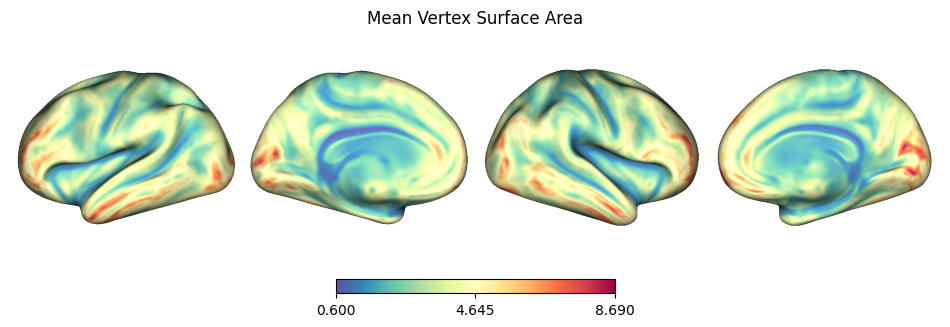

In [10]:
medial_wall_mask_values = CAP_tools.utils.cifti_map(None, np.ones(59412), example_cifti)
medial_wall_mask_L = np.isnan(medial_wall_mask_values["left"])
medial_wall_mask_R = np.isnan(medial_wall_mask_values["right"])
medial_wall_mask_64k = np.hstack([medial_wall_mask_L, medial_wall_mask_R])

generic_area_file = "/data/data4/earlycort_7114/*/MNINonLinear/fsaverage_LR32k/*.{side}.midthickness.32k_fs_LR.area.func.gii"

all_L_area_files = glob.glob(generic_area_file.format(side="L"))
all_R_area_files = glob.glob(generic_area_file.format(side="R"))

L_SA_all_32k = np.expand_dims(np.array([nb.load(sf).darrays[0].data for sf in all_L_area_files]), -1)
R_SA_all_32k = np.expand_dims(np.array([nb.load(sf).darrays[0].data for sf in all_R_area_files]), -1)
SA_all_64k = np.concatenate([L_SA_all_32k, R_SA_all_32k], axis=1)
SA_all_cortex = SA_all_64k[:, ~medial_wall_mask_64k]
mean_SA_cortex = np.mean(SA_all_cortex, axis=0)

mean_L_SA = np.mean(L_SA_all_32k, axis=0)[:, 0]
mean_R_SA = np.mean(R_SA_all_32k, axis=0)[:, 0]

mean_SA_values = {"left": mean_L_SA, "right": mean_R_SA}
fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(mean_SA_values, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title("Mean Vertex Surface Area")

# TODO: FC stability

## Load FC data

In [47]:
def sparse_std(sparse_matrix):
    if not issparse(sparse_matrix):
        raise ValueError("Input must be a sparse matrix.")
    mean = sparse_matrix.mean()
    sq_diff = sparse_matrix.copy()
    sq_diff.data = (sparse_matrix.data - mean) ** 2
    variance = sq_diff.sum() / sparse_matrix.size
    return np.sqrt(variance)

In [64]:
sc_s = []
tr_label_s = []

for max_trs in tqdm([1200, 300, 2400, 3300, None]):
    cached_network_save_paths = pm.utils.cache_tmp_path(path_sets[max_trs]["voxel_FC_save_paths"], write_cache=True, pbar=True)
    for network_path in tqdm(cached_network_save_paths, desc="Loading PMs", leave=False):
        sc = scipy.sparse.load_npz(network_path)
        sc_s.append(sc)
        tr_label_s.append(max_trs)

tr_label_s = np.array([i if i else 3600 for i in tr_label_s])

  0%|          | 0/5 [00:00<?, ?it/s]

Caching paths in ~/_tmp:   0%|          | 0/177 [00:00<?, ?it/s]

Loading PMs:   0%|          | 0/177 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [68]:
sc_1 = sc_s[1]

In [66]:
sc.mean(), sc_1.mean()

(np.float32(0.0005112417), np.float32(7.378641e-05))

In [166]:
def sparse_unit_norm(sc):
    """ """
    total_size = np.prod(sc.shape)
    nz = total_size - sc.nnz
    
    zero_data_demeaned_value = 0 - sc.mean()
    data_demeaned = sc.data - sc.mean()
    
    sum_var = (np.sum(data_demeaned ** 2) + nz * (zero_data_demeaned_value ** 2))
    
    zero_data_norm = zdata_demeaned / np.sqrt(sum_var)
    sc_norm = sc.copy()
    sc_norm.data = data_demeaned / np.sqrt(sum_var)
    return sc_norm, zero_data_norm

In [178]:
def sparse_matrix_corr(sc1, sc2):
    """ """
    sc1_norm, sc1_norm_zero_value = sparse_unit_norm(sc1)
    sc2_norm, sc2_norm_zero_value = sparse_unit_norm(sc2)
    
    combined_sc = sc1_norm + sc2_norm
    sc1_norm_expand = combined_sc.copy()
    sc1_norm_expand[combined_sc.nonzero()] = sc1_norm_zero_value
    sc1_norm_expand[sc1_norm.nonzero()] = sc1_norm.data

    sc2_norm_expand = combined_sc.copy()
    sc2_norm_expand[combined_sc.nonzero()] = sc2_norm_zero_value
    sc2_norm_expand[sc2_norm.nonzero()] = sc2_norm.data

    return sc1_norm_expand, sc2_norm_expand
    
    # (np.sum(sc1_norm.data * norm_sc2.data) + (total_size - combined_sc.nnz) * (zdata_normed * zdata_normed))

In [183]:
sc1_norm_expand, sc2_norm_expand = sparse_matrix_corr(sc, sc_1)

In [180]:
sc1_norm_expand

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8332312 stored elements and shape (91282, 91282)>

In [181]:
sc2_norm_expand

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8332312 stored elements and shape (91282, 91282)>

In [182]:
sc

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 8332312 stored elements and shape (91282, 91282)>

In [148]:
total_size = np.prod(sc.shape)
nz = total_size - sc.nnz

zdata_demeaned = 0 - sc.mean()
data_demeaned = sc.data - sc.mean()

var = (np.sum(data_demeaned ** 2) + nz * (zdata_demeaned ** 2))

data_normed = data_demeaned / np.sqrt(var)
zdata_normed = zdata_demeaned / np.sqrt(var)

In [149]:
norm_sc = sc.copy()
norm_sc.data = data_normed

In [156]:
combined_sc = norm_sc + norm_sc
combined_sc.data = norm_sc.data * norm_sc.data

In [162]:
(np.sum(norm_sc.data * norm_sc.data) + (total_size - combined_sc.nnz) * (zdata_normed * zdata_normed))

np.float64(0.999998648458331)

In [116]:
np.sqrt(var), sc.mean()

(np.float64(0.01634599247738243), np.float32(0.0005112417))

In [92]:
combined_sc = sc * sc_1

In [91]:
sc[combined_sc.nonzero()]

matrix([[0.43862948, 0.43961185, 0.44048217, ..., 0.50986034, 0.94554937,
         0.5162862 ]], shape=(1, 15356242), dtype=float32)

In [83]:
row_u = np.union1d(sc.nonzero()[0], sc_1.nonzero()[0])
col_u = np.union1d(sc.nonzero()[1], sc_1.nonzero()[1])

In [80]:
len(row_overlap) / 8332312

0.010393273799636884

# Size Stability Metrics

In [18]:
vni_s, vns_s = [], []
tr_label_s = []
for max_trs in tqdm([300, 1200, 2400, 3300, None]):

    cached_network_save_paths = pm.utils.cache_tmp_path(path_sets[max_trs]["network_save_paths"], write_cache=True)
    for network_path in tqdm(cached_network_save_paths, desc="Loading PMs", leave=False):
        vni, vns = np.load(network_path)
        vns_s.append(vns)
        vni_s.append(vni)
        tr_label_s.append(max_trs)

vns_s = np.array(vns_s)
vni_s = np.array(vni_s).astype(int)
tr_label_s = np.array(tr_label_s)
tr_label_s = np.array([i if i else 3600 for i in tr_label_s])

  0%|          | 0/5 [00:00<?, ?it/s]

Loading PMs:   0%|          | 0/177 [00:00<?, ?it/s]

Loading PMs:   0%|          | 0/177 [00:00<?, ?it/s]

Loading PMs:   0%|          | 0/177 [00:00<?, ?it/s]

Loading PMs:   0%|          | 0/177 [00:00<?, ?it/s]

Loading PMs:   0%|          | 0/177 [00:00<?, ?it/s]

In [16]:
vert_counts = np.array([(vns_s == net).mean(axis=1) for net in tqdm(network_labels, leave=False)]).T

  0%|          | 0/21 [00:00<?, ?it/s]

In [17]:
def percent_clip(arr, lower=None, upper=None):
    v = arr[~np.isnan(arr)]
    return np.clip(arr, np.percentile(v, lower or 0), np.percentile(v, upper or 100))

def vertex_plot(values, template_cifti, ax=None, pclip=(None, None), **kwargs):
    """ """
    values = percent_clip(values, *pclip)
    values = CAP_tools.utils.cifti_map(None, values, template_cifti)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    return sfm.surface_plot(values, ax=ax, **kwargs)

In [18]:
subject_s_big = np.tile(subjects, (len(np.unique(tr_label_s))))

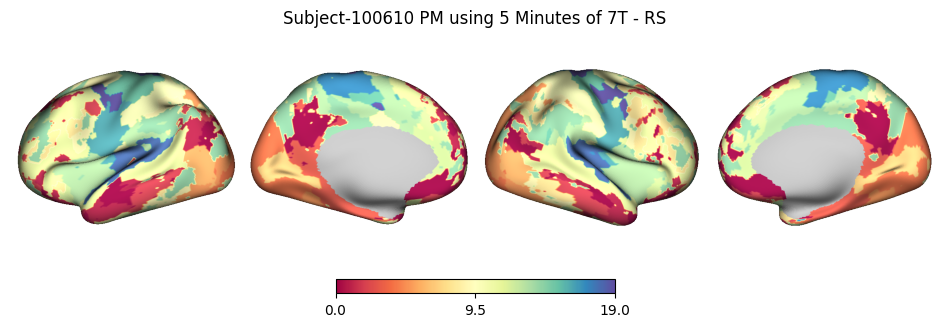

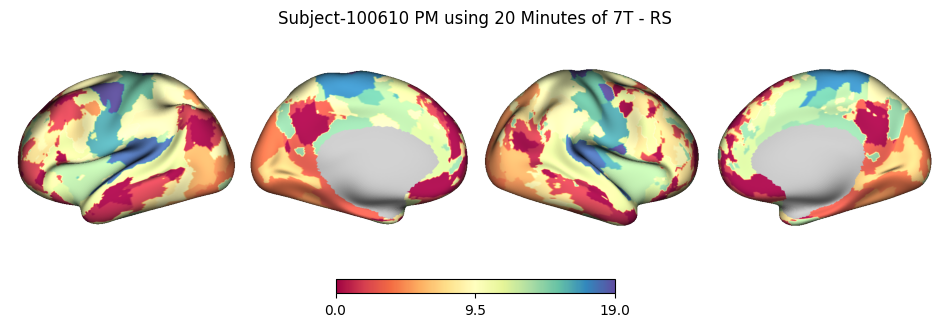

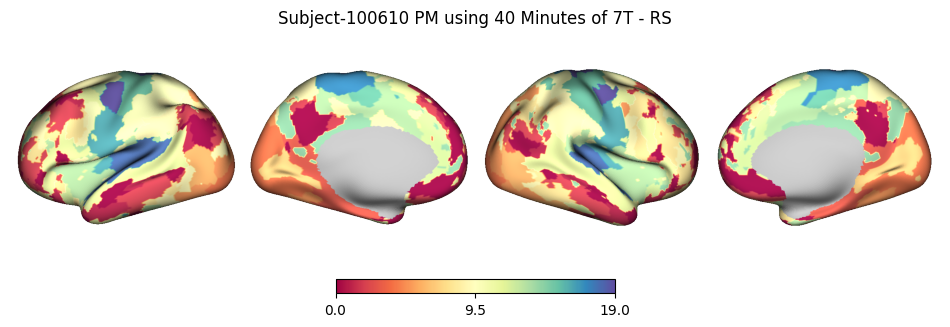

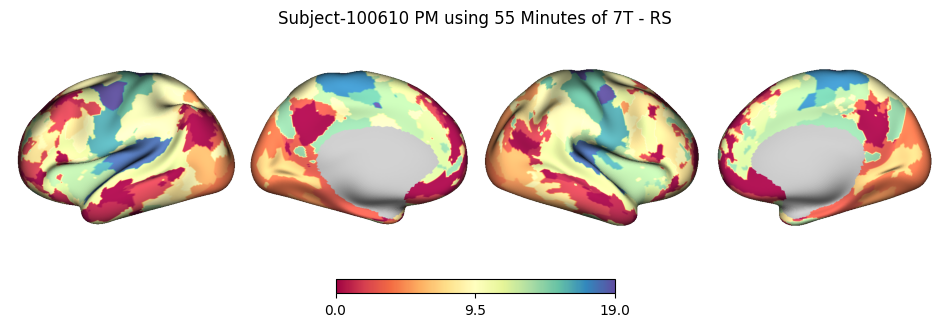

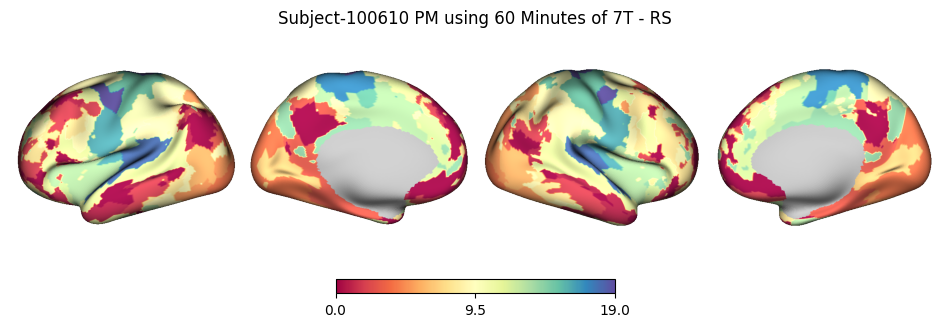

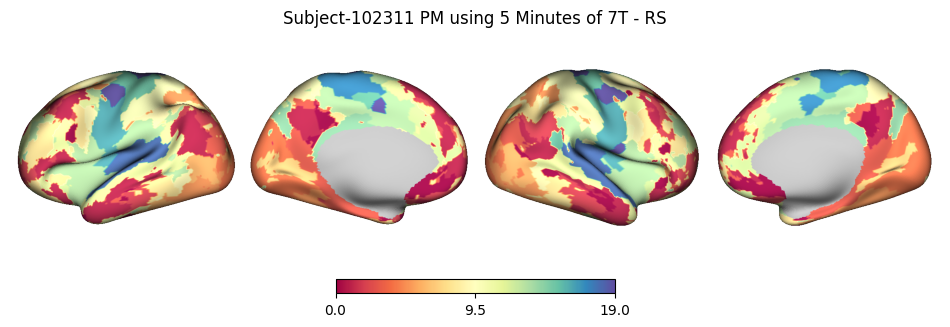

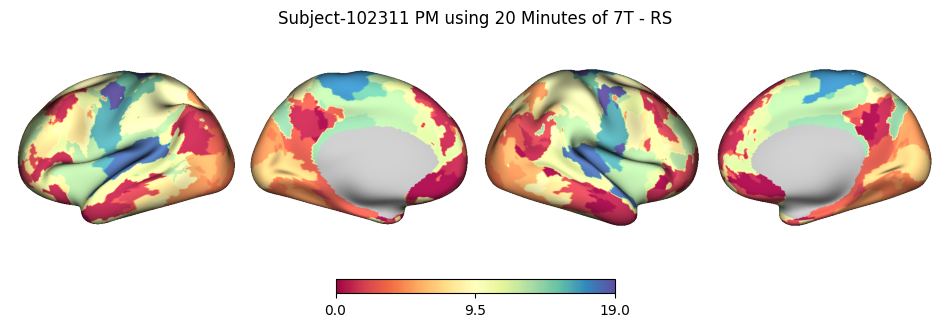

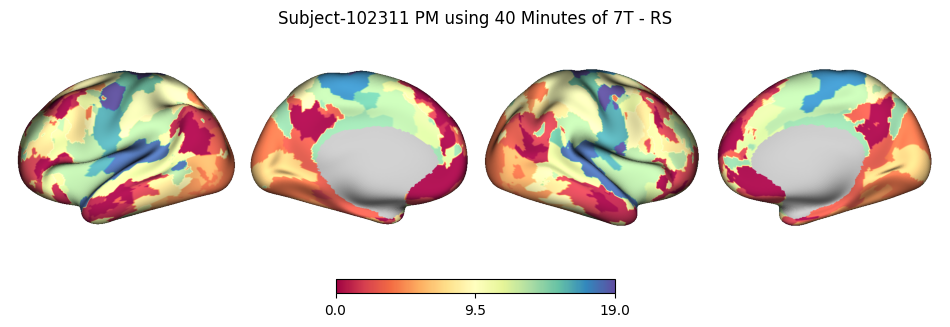

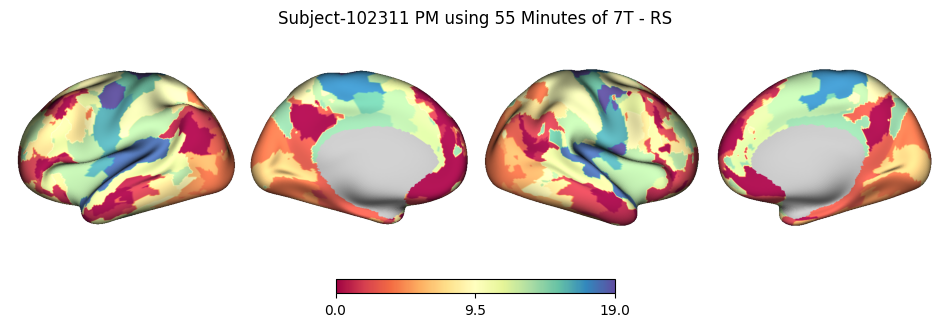

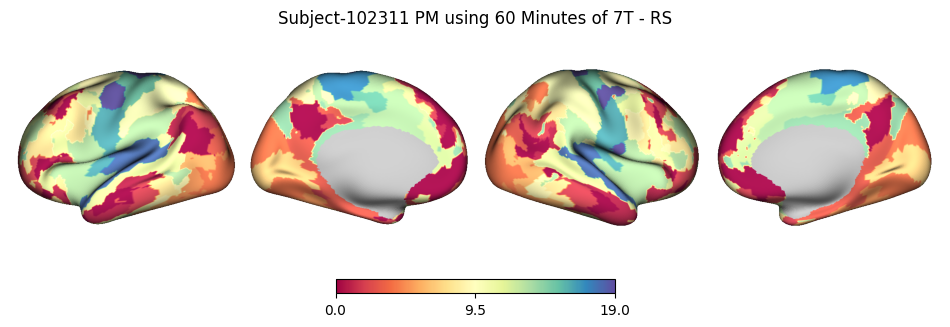

In [20]:
for subject in subjects[:2]:
    sid = subject_s_big == subject
    
    vni_subject_set = vni_s[sid]
    tr_subject_set = tr_label_s[sid]
    
    for vni_subject_tr, tr_subject in zip(vni_subject_set, tr_subject_set):
        ax, _ = vertex_plot(vni_subject_tr, example_cifti, cmap=plt.cm.Spectral)
        ax.set_title(f"Subject-{subject} PM using {tr_subject/60:0.0f} Minutes of 7T - RS")

# Dice Stability over Time

In [21]:
def dice_coef(s1, s2):
    """ """
    assert s1.dtype == s2.dtype

    if not s1.dtype == bool:
        return np.mean([dice_coef(s1 == value, s2 == value) for value in np.unique(np.hstack([s1, s2]))])

    card_sum = np.nansum(s1) + np.nansum(s2)
    assert card_sum > 0
    
    return 2 * np.nansum(s1 * s2) / card_sum

In [22]:
network_dice_s = []
for subject in tqdm(subjects):
    sid = subject_s_big == subject
    network_dice_s.append([dice_coef(vni_tr, vni_s[sid][-1]) for vni_tr in vni_s[sid]])
network_dice_s = np.array(network_dice_s)

  0%|          | 0/177 [00:00<?, ?it/s]

In [23]:
net_spec_dices = {i: [] for i in range(20)}

for subject in tqdm(subjects):
    sid = subject_s_big == subject
    for n in net_spec_dices:
        net_spec_dices[n].append([dice_coef(vni_tr == n, vni_s[sid][-1] == n) for vni_tr in vni_s[sid]])

net_spec_dices = {i: np.array(v) for i, v in net_spec_dices.items()}

  0%|          | 0/177 [00:00<?, ?it/s]

In [24]:
trs = np.sort(np.unique(tr_label_s))

In [25]:
z = np.array([v[:, :-1] for v in net_spec_dices.values()])
trz = (np.tile(trs[:-1], (*z.shape[:-1], 1)) / 60).astype(int)
nz = np.tile(network_labels[:-1], (*z.T.shape[:-1], 1)).T

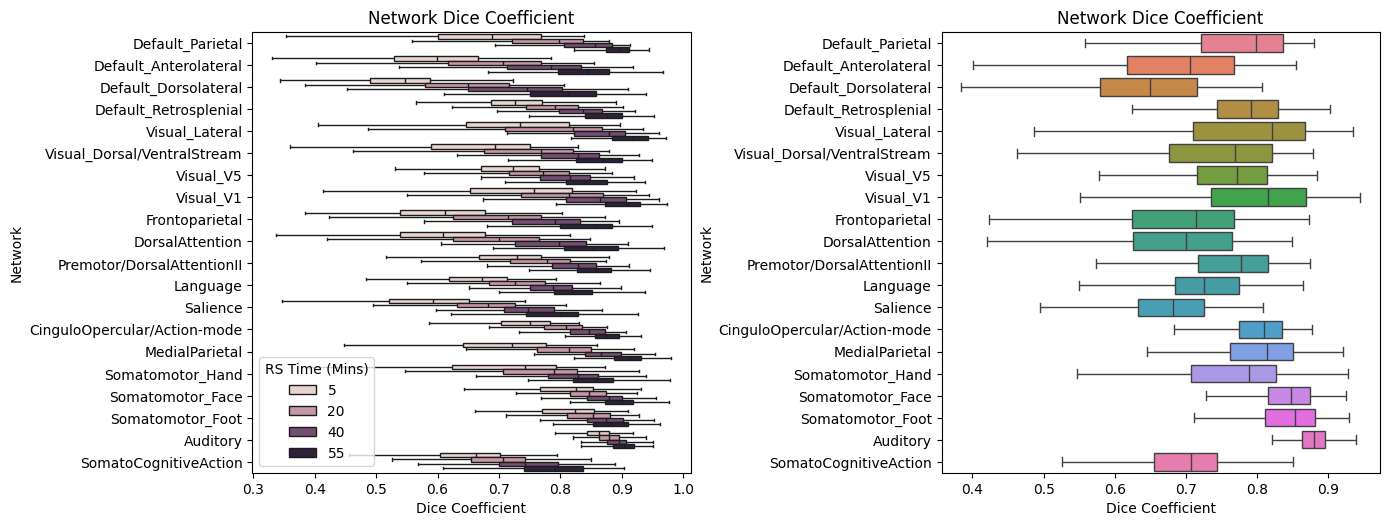

In [26]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 5))
fig.tight_layout(w_pad=15)
sns.boxplot(y=nz.ravel(), x=z.ravel(), hue=trz.ravel(), showfliers=False, ax=a0)
a0.legend(title="RS Time (Mins)")

x = np.hstack([v[:, 1] for i, v in net_spec_dices.items()])
y=np.tile(network_labels[:-1], (177, 1)).T.ravel()
sns.boxplot(y=y, x=x, hue=y, showfliers=False, ax=a1)
a0.set(xlabel="Dice Coefficient", ylabel="Network", title="Network Dice Coefficient")
a1.set(xlabel="Dice Coefficient", ylabel="Network", title="Network Dice Coefficient");

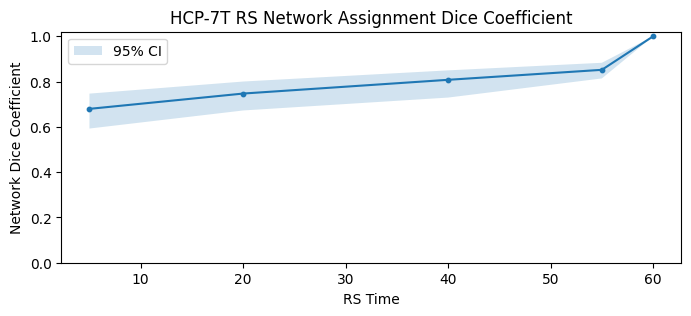

In [27]:
m = np.mean(network_dice_s, axis=0)
low_lim, high_lim = np.percentile(network_dice_s, 2.5, axis=0), np.percentile(network_dice_s, 97.5, axis=0)
times = trs / 60

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(times, m, color="C0")
ax.scatter(times, m, color="C0", s=10)
ax.fill_between(times, low_lim, high_lim, alpha=0.2, label="95% CI")
# ax.axhline(1/20, linestyle="--", color="C3", alpha=1, linewidth=1, label="Random Chance")
ax.set(title="HCP-7T RS Network Assignment Dice Coefficient", xlabel="RS Time", ylabel="Network Dice Coefficient")
ax.set_ylim(0, None)
ax.legend()

(<Axes: >, <surfplot.plotting.Plot at 0x33bbd08d0>)

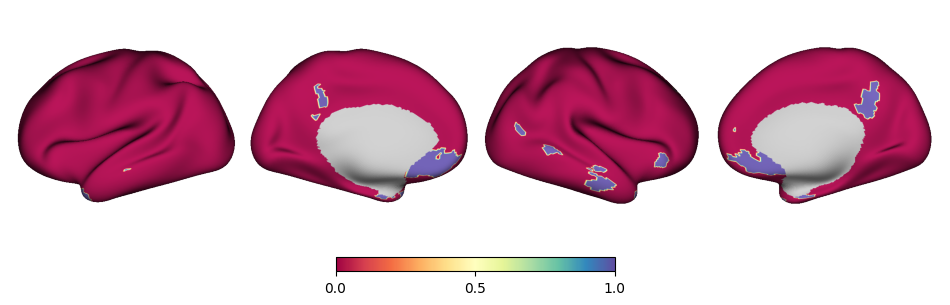

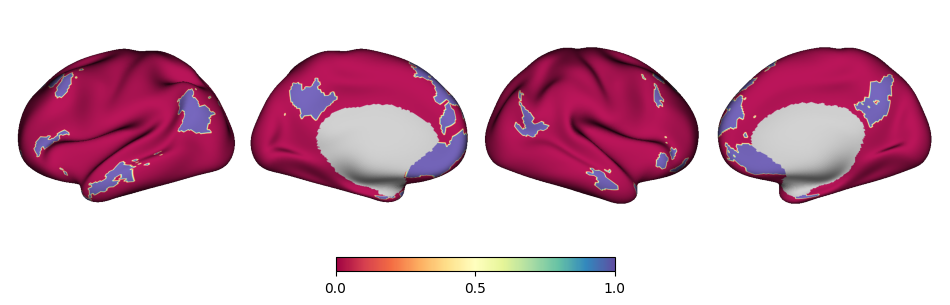

In [28]:
vertex_plot((vni_subject_set[1] == 0) * 1, example_cifti, cmap=plt.cm.Spectral)
vertex_plot((vni_subject_set[2] == 0) * 1, example_cifti, cmap=plt.cm.Spectral)

In [29]:
compare_table = np.arange(np.max(vni_s) + 2).reshape(1, 1, -1)
ni_index_set = np.expand_dims(vni_s, 2) == compare_table
sizes = mean_SA_cortex * ni_index_set
size_frac = sizes / sizes.sum(axis=(1, 2), keepdims=True)
network_sizes = size_frac.sum(axis=1)

In [30]:
EC_vert_size_csv = "/data/data7/network_control/projects/precision_mapping/notebooks/scratch/EC_vert_count_data.csv"
EC_df = pd.read_csv(EC_vert_size_csv)
szp_index = EC_df["subject"].str.contains("_08_").values
EC_df["TR"] = np.array(["HC", "SzP"])[szp_index * 1]

# EC_sizes_csv = "/data/data7/network_control/projects/voxel_analysis/notebooks/scratch/EC_sizes_data.csv"
# EC_df = pd.read_csv(EC_sizes_csv)
# szp_index = EC_df["subject"].str.contains("_08_").values
# EC_df["TR"] = np.array(["HC", "SzP"])[szp_index * 1]

In [31]:
df = pd.DataFrame(vert_counts, columns=network_labels)
# df = pd.DataFrame(network_sizes, columns=network_labels)
df["subject"] = np.tile(subjects, (len(np.unique(tr_label_s))))
df["TR"] = tr_label_s

# df = pd.concat([df, EC_df])
mdf = pd.melt(df, id_vars=["subject", "TR"], var_name="network", value_name="n_vertices")

<Axes: xlabel='n_vertices', ylabel='network'>

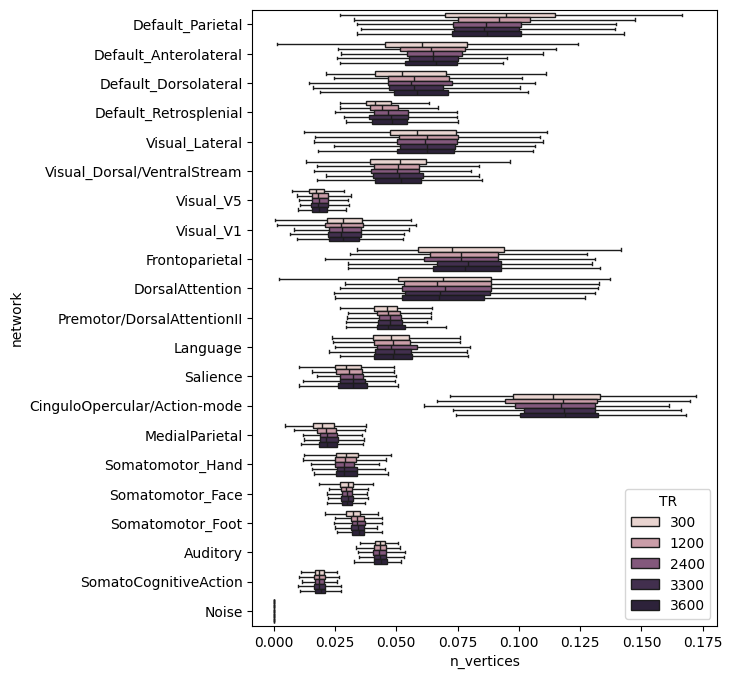

In [32]:
fig, ax = plt.subplots(figsize=(6, 8))
sns.boxplot(data=mdf, y="network", x="n_vertices", hue="TR", showfliers=False, ax=ax)
# sns.boxplot(data=mdf, y="network", x="n_vertices", hue="TR", showfliers=False, ax=ax)

In [33]:
hcp_1200 = df.query("TR == 1200")
szp_df = df.query("TR == 'SzP'")
hc_df = df.query("TR == 'HC'")

hcp_df = df.loc[df["TR"].apply(lambda s: isinstance(s, int))]

In [34]:
t_s, p_s = scipy.stats.ttest_ind(hcp_1200[network_labels], hc_df[network_labels])

for n, t, p in zip(network_labels, t_s, p_s):
    if p < 0.05:
        print(f"{n}:: {t:0.2f} {p:0.5f}")

/var/folders/p0/zng86kys7t3578bm_dw7qjym00014h/T/ipykernel_3174/55583869.py:1: SmallSampleWarning: All axis-slices of one or more sample arguments are too small; all elements of returned arrays will be NaN. See documentation for sample size requirements.
  t_s, p_s = scipy.stats.ttest_ind(hcp_1200[network_labels], hc_df[network_labels])


In [35]:
mtr_df = pd.melt(df[network_labels].groupby(df["TR"]).std().reset_index(), id_vars=["TR"], var_name="network", value_name="std")

In [36]:
size_corrs = []
lang_size_frac_diff_s = []
lang_sizes_s = []
for subject, subj_df in hcp_df.groupby("subject"):
    z = subj_df.sort_values("TR").drop("subject", axis=1).set_index("TR").T.corr()[3600]
    trs = z.index.values
    size_corrs.append(z.values)
    
    lang_sizes = subj_df.sort_values("TR").set_index("TR")["Language"]
    lang_sizes_s.append(lang_sizes)
    lang_size_frac_diff_s.append((lang_sizes.values[-1] - lang_sizes.values) / lang_sizes.values[-1])

size_corrs = np.array(size_corrs) ** 2
trs = trs.astype(int)
lang_size_frac_diff_s = np.array(lang_size_frac_diff_s)

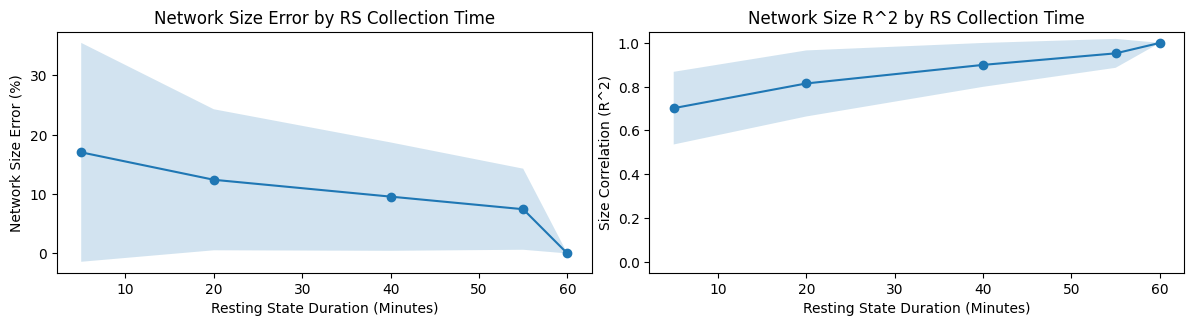

In [53]:
values = lang_size_frac_diff_s * 100

m = np.mean(np.abs(values), axis=0)
s = np.std(np.abs(values), axis=0)
times = trs / 60

fig, (ax, a1) = plt.subplots(1, 2, figsize=(12, 3))
fig.tight_layout()
ax.plot(times, m)
ax.scatter(times, m, color="C0")
ax.fill_between(times, m - s, m + s, alpha=0.2)
ax.set(xlabel="Resting State Duration (Minutes)", ylabel="Network Size Error (%)",
       title="Network Size Error by RS Collection Time")
# ax.set_ylim(None, 100)

t = trs / 60
m, std = np.mean(size_corrs, axis=0),  np.std(size_corrs, axis=0)

a1.plot(t, m)
a1.scatter(t, m, color="C0")
a1.fill_between(t, m - std, m + std, alpha=0.2)
a1.set_ylim(-0.05, 1.05)
a1.set(xlabel="Resting State Duration (Minutes)", ylabel="Size Correlation (R^2)",
       title="Network Size R^2 by RS Collection Time");

# sns.kdeplot(lang_size_frac_diff_s[:, 0].ravel(), ax=a1)
# sns.kdeplot(lang_size_frac_diff_s[:, 1].ravel(), ax=a1)
# sns.kdeplot(lang_size_frac_diff_s[:, 2].ravel(), ax=a1)

# Network Size Stability
# TODOS:
- [] Plot individual parcellation over various TR step sizes
- [] Plot network assignment DICE overlap score over TR step sizes
- [] Plot network size over TR step sizes

In [159]:
def ttest(var, index):
    """ """
    assert all(np.isin(index, [True, False]))
    
    ni = ~np.isnan(var)
    if isinstance(var, pd.core.frame.DataFrame):
        return scipy.stats.ttest_1samp(var.loc[index & ni], var.loc[~index & ni])

    return scipy.stats.ttest_ind(var[index & ni], var[~index & ni])